<a href="https://colab.research.google.com/github/Hgrcrls/o3source_location/blob/main/ozone_source_localization_v2/01_preprocess_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Configuração do ambiente
Ambiente detectado: Google Colab
Mounted at /content/drive

[INFO] Diretório do projeto: /content/drive/MyDrive/Iniciacao_cientifica/Tarefa_1/ozone_source_localization_v2
[INFO] Pasta de origem: /content/drive/MyDrive/Iniciacao_cientifica/Tarefa_1/ozone_source_localization_v2/data/orig
[INFO] Pasta de processamento: /content/drive/MyDrive/Iniciacao_cientifica/Tarefa_1/ozone_source_localization_v2/data/processed

Verificação da pasta de saída
Pasta: /content/drive/MyDrive/Iniciacao_cientifica/Tarefa_1/ozone_source_localization_v2/data/processed
Total de arquivos encontrados: 18 

Arquivos presentes:
- Simul27_S53_Radiador1.csv
- dataset_report.txt
- Simul29_S55_Radiador1.csv
- Simul08_S22_Radiador1.csv
- Simul04_S14_Radiador1.csv
- Simul10_S24_Radiador1.csv
- Simul05_S15_Radiador1.csv
- Simul01_S11_Radiador1.csv
- Simul03_S13_Radiador1.csv
- Simul02_S12.csv
- Simul12_S26_Radiador1.csv
- Simul13_S31_Radiador1.csv
- Simul15_S33_Radiador1.csv
- Simul20_S42_Radiado

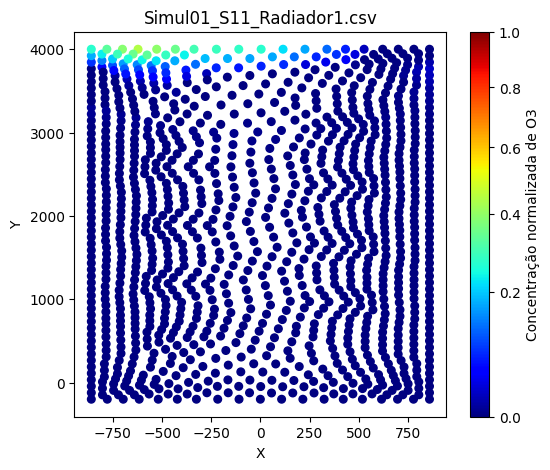


Pipeline finalizado com sucesso!


In [ ]:
"""
Pipeline de pré-processamento do dataset de concentração de ozônio.

Funcionalidades:
- Montagem automática do Google Drive
- Conversão de arquivos .ods para .csv
- Ignorar arquivos com Radiador2
- Manter arquivos sem Radiador
- Remover valores negativos
- Normalização global
- Relatório automático do dataset
- Visualização de exemplo
"""

# =========================================================
# IMPORTAÇÕES
# =========================================================

!pip install -q pandas matplotlib odfpy

import os
import sys
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from datetime import datetime
from pathlib import Path


# =========================================================
# CONSTANTES
# =========================================================

PLOT_POINT_SIZE = 30
PLOT_GAMMA = 0.7


# =========================================================
# DETECTAR COLAB
# =========================================================

def is_colab():
    return "google.colab" in sys.modules


# =========================================================
# DETECTAR RAIZ DO PROJETO
# =========================================================

def find_project_root():
    """
    Procura automaticamente a raiz do projeto
    procurando a pasta 'data'
    """

    current = Path.cwd()

    for parent in [current] + list(current.parents):

        if (parent / "data").exists():
            return parent

    return current


# =========================================================
# CONFIGURAÇÃO DO AMBIENTE
# =========================================================

def configure_paths():

    print("\n==============================")
    print("Configuração do ambiente")
    print("==============================")

    if is_colab():

        print("Ambiente detectado: Google Colab")

        from google.colab import drive
        drive.mount("/content/drive")

        base_path = Path("/content/drive/MyDrive/Iniciacao_cientifica/Tarefa_1/ozone_source_localization_v2")

    else:

        print("Ambiente detectado: Execução local")

        base_path = find_project_root()

    data_path = base_path / "data"

    orig_path = data_path / "orig"
    processed_path = data_path / "processed"
    results_path = base_path / "results"

    # cria pastas automaticamente
    orig_path.mkdir(parents=True, exist_ok=True)
    processed_path.mkdir(parents=True, exist_ok=True)
    results_path.mkdir(parents=True, exist_ok=True)

    print("\n[INFO] Diretório do projeto:", base_path)
    print("[INFO] Pasta de origem:", orig_path)
    print("[INFO] Pasta de processamento:", processed_path)

    return orig_path, processed_path, results_path


# =========================================================
# VERIFICAR PASTA PROCESSED
# =========================================================

def clean_directory(path):

    files = os.listdir(path)

    print("\n==============================")
    print("Verificação da pasta de saída")
    print("==============================")

    print("Pasta:", path)
    print("Total de arquivos encontrados:", len(files), "\n")

    if len(files) == 0:
        print("Pasta já está vazia.\n")
        return

    print("Arquivos presentes:")

    for f in files:
        print("-", f)

    answer = input("\nDeseja apagar os arquivos antigos antes de rodar? (s/n): ").lower()

    if answer == "s":

        for f in files:

            file_path = os.path.join(path, f)

            try:

                if os.path.isfile(file_path):
                    os.remove(file_path)

                else:
                    shutil.rmtree(file_path)

            except Exception as e:

                print("Erro ao remover:", f, e)

        print("\nPasta limpa.\n")

    else:

        print("\nArquivos antigos serão mantidos.\n")


# =========================================================
# CONVERTER ODS
# =========================================================

def convert_ods_to_csv(orig_path):

    print("\n[INFO] Verificando arquivos .ods...")

    for filename in os.listdir(orig_path):

        if filename.endswith(".ods"):

            ods_path = orig_path / filename

            df = pd.read_excel(ods_path, engine="odf")

            csv_name = filename.replace(".ods", ".csv")

            csv_path = orig_path / csv_name

            df.to_csv(csv_path, index=False)

            os.remove(ods_path)

            print("Convertido:", filename)

    print("[INFO] Conversão concluída\n")


# =========================================================
# CARREGAR CSV
# =========================================================

def load_csv_files(orig_path):

    files = sorted([f for f in os.listdir(orig_path) if f.endswith(".csv")])

    if len(files) == 0:
        raise Exception(
            f"Nenhum arquivo CSV encontrado em:\n{orig_path}\n"
            "Coloque os arquivos na pasta data/orig"
        )

    processed_files = []
    ignored_files = []

    for f in files:

        if "Radiador2" in f:
            ignored_files.append(f)
        else:
            processed_files.append(f)

    print("\n==============================")
    print("Relatório de arquivos")
    print("==============================")

    print("Total encontrados:", len(files))
    print("Processados:", len(processed_files))
    print("Ignorados (Radiador2):", len(ignored_files))

    print("\nArquivos processados:")

    for f in processed_files:
        print("-", f)

    print("\nArquivos ignorados:")

    for f in ignored_files:
        print("-", f)

    print()

    dataframes = []

    for f in processed_files:

        path = orig_path / f

        df = pd.read_csv(
            path,
            sep=None,
            engine="python",
            comment="%",
            header=None
        )

        df.columns = ["x", "y", "value"]

        dataframes.append(df)

    return dataframes, processed_files, ignored_files


# =========================================================
# REMOVER NEGATIVOS
# =========================================================

def remove_negatives(dataframes):

    print("[INFO] Removendo valores negativos")

    for df in dataframes:
        df["value"] = df["value"].clip(lower=0)

    print("[INFO] Remoção concluída\n")


# =========================================================
# NORMALIZAÇÃO GLOBAL
# =========================================================

def normalize_global(dataframes):

    print("[INFO] Normalizando dados")

    global_min = min(df["value"].min() for df in dataframes)
    global_max = max(df["value"].max() for df in dataframes)

    for df in dataframes:

        df["value"] = (df["value"] - global_min) / (global_max - global_min)
        df["value"] = df["value"].clip(0, 1)

    print(f"[INFO] Normalização concluída (min={global_min}, max={global_max})\n")

    return global_min, global_max


# =========================================================
# SALVAR ARQUIVOS
# =========================================================

def save_processed(dataframes, files, processed_path):

    print("[INFO] Salvando arquivos")

    for df, f in zip(dataframes, files):

        path = processed_path / f

        df.to_csv(path, index=False)

    print("[INFO] Salvamento concluído\n")


# =========================================================
# GERAR RELATÓRIO
# =========================================================

def generate_dataset_report(processed_path, processed_files, ignored_files, gmin, gmax):

    report_path = processed_path / "dataset_report.txt"

    with open(report_path, "w") as f:

        f.write("DATASET REPORT\n")
        f.write("========================\n\n")

        f.write("Data da execução:\n")
        f.write(str(datetime.now()) + "\n\n")

        f.write("Arquivos processados:\n")

        for name in processed_files:
            f.write(name + "\n")

        f.write("\nArquivos ignorados (Radiador2):\n")

        for name in ignored_files:
            f.write(name + "\n")

        f.write("\nNormalização global:\n")
        f.write(f"min = {gmin}\n")
        f.write(f"max = {gmax}\n")

    print("[INFO] dataset_report.txt gerado\n")


# =========================================================
# VISUALIZAÇÃO
# =========================================================

def plot_field(df, filename=None):

    plt.figure(figsize=(6,5))

    sc = plt.scatter(
        df["x"],
        df["y"],
        c=df["value"],
        s=PLOT_POINT_SIZE,
        norm=PowerNorm(gamma=PLOT_GAMMA, vmin=0, vmax=1),
        cmap="jet"
    )

    plt.colorbar(sc, label="Concentração normalizada de O3")

    plt.xlabel("X")
    plt.ylabel("Y")

    if filename:
        plt.title(filename)

    plt.show()


# =========================================================
# MAIN
# =========================================================

def main():

    orig_path, processed_path, results_path = configure_paths()

    clean_directory(processed_path)

    convert_ods_to_csv(orig_path)

    dataframes, files, ignored = load_csv_files(orig_path)

    remove_negatives(dataframes)

    gmin, gmax = normalize_global(dataframes)

    save_processed(dataframes, files, processed_path)

    generate_dataset_report(processed_path, files, ignored, gmin, gmax)

    print("Arquivos finais salvos:", len(files))

    print("\n[INFO] Visualizando exemplo")

    plot_field(dataframes[0], files[0])

    print("\nPipeline finalizado com sucesso!")


# =========================================================
# EXECUÇÃO
# =========================================================

if __name__ == "__main__":
    main()